In [1]:
import warnings

In [2]:
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd

In [4]:
from sklearn.model_selection import train_test_split


In [5]:
pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

In [6]:
pima_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

In [7]:
pima_df = pd.read_csv(pima_url, header=None, names=pima_cols)


In [8]:
X_pima = pima_df[pima_cols[:-1]]

In [9]:
y_pima = pima_df['Outcome']

In [10]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_pima, y_pima, test_size=0.20, stratify=y_pima, random_state=42
)

In [11]:
print("Pima Classification Training Set Shape:", X_train_c.shape)

Pima Classification Training Set Shape: (614, 8)


In [12]:
print("Pima Classification Test Set Shape:", X_test_c.shape)


Pima Classification Test Set Shape: (154, 8)


In [13]:
from sklearn.tree import DecisionTreeClassifier


In [14]:
from sklearn.metrics import accuracy_score, classification_report


In [15]:
tree_clf = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_clf.fit(X_train_c, y_train_c)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [16]:
clf_preds = tree_clf.predict(X_test_c)


In [17]:
print(f"Decision Tree Classifier Test Accuracy: {accuracy_score(y_test_c, clf_preds) * 100:.2f}%\n")


Decision Tree Classifier Test Accuracy: 79.87%



In [18]:
print("--- Classification Report ---")


--- Classification Report ---


In [19]:
print(classification_report(y_test_c, clf_preds, target_names=['No Diabetes (0)', 'Diabetes (1)']))


                 precision    recall  f1-score   support

No Diabetes (0)       0.82      0.88      0.85       100
   Diabetes (1)       0.74      0.65      0.69        54

       accuracy                           0.80       154
      macro avg       0.78      0.76      0.77       154
   weighted avg       0.80      0.80      0.80       154



In [20]:
import matplotlib.pyplot as plt


In [21]:
from sklearn.tree import plot_tree


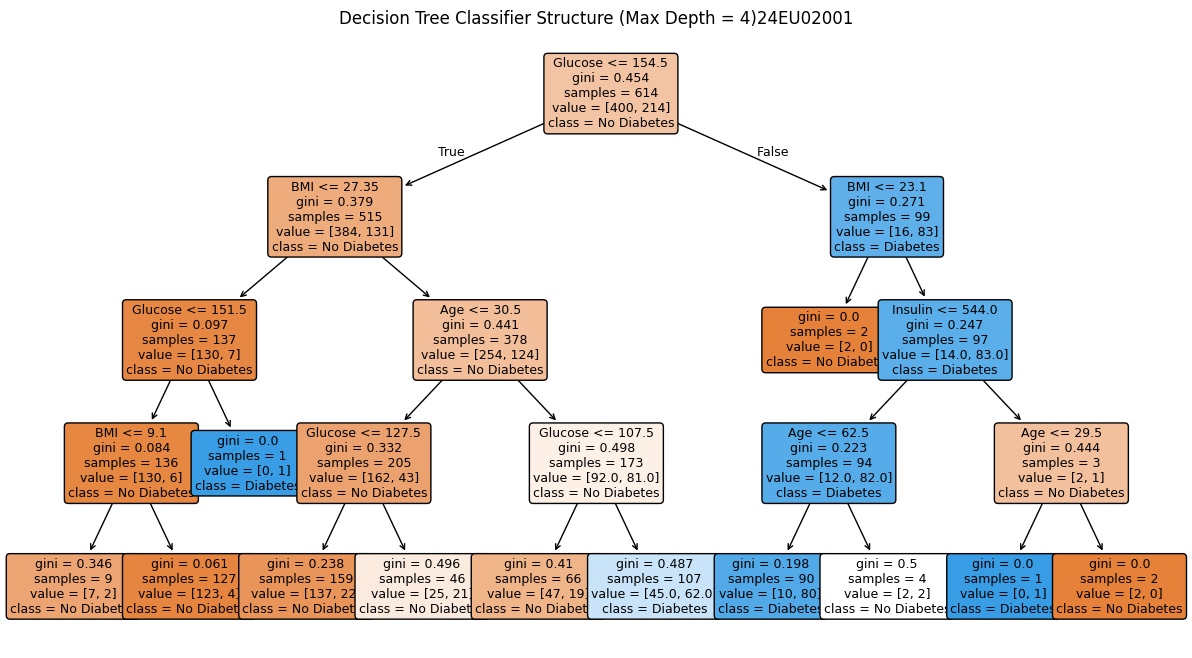

In [22]:
plt.figure(figsize=(15, 8))
plot_tree(
    tree_clf,
    feature_names=pima_cols[:-1],
    class_names=['No Diabetes', 'Diabetes'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree Classifier Structure (Max Depth = 4)24EU02001")
plt.show()

In [23]:
from sklearn.tree import DecisionTreeRegressor


In [24]:
from sklearn.preprocessing import StandardScaler


In [25]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"


In [26]:
boston_df = pd.read_csv(boston_url)


In [27]:
boston_features = [col for col in boston_df.columns if col != 'medv']


In [28]:
boston_df = pd.read_csv(boston_url)


In [29]:
boston_features = [col for col in boston_df.columns if col != 'medv']


In [30]:
X_boston = boston_df[boston_features]


In [31]:
y_boston = boston_df['medv']


In [32]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_boston, y_boston, test_size=0.20, random_state=42)


In [33]:
scaler_r = StandardScaler()


In [34]:
X_train_r_scaled = scaler_r.fit_transform(X_train_r)


In [35]:
X_test_r_scaled = scaler_r.transform(X_test_r)


In [36]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=42)


In [37]:
tree_reg.fit(X_train_r_scaled, y_train_r)


DecisionTreeRegressor(max_depth=5, random_state=42)

In [38]:
print("Decision Tree Regressor trained successfully. Max Depth set to 5.")


Decision Tree Regressor trained successfully. Max Depth set to 5.


In [39]:
from sklearn.metrics import mean_squared_error, r2_score


In [40]:
import numpy as np


In [41]:
reg_preds = tree_reg.predict(X_test_r_scaled)


In [42]:
mse_val = mean_squared_error(y_test_r, reg_preds)


In [43]:
rmse_val = np.sqrt(mse_val)


In [44]:
r2_val = r2_score(y_test_r, reg_preds)


In [45]:
print(f"Mean Squared Error (MSE): {mse_val:.4f}")


Mean Squared Error (MSE): 8.5539


In [46]:
print(f"Root Mean Squared Error (RMSE): {rmse_val:.4f} ($1000s)")


Root Mean Squared Error (RMSE): 2.9247 ($1000s)


In [47]:
print(f"R2 Coefficient of Determination: {r2_val:.4f}\n")


R2 Coefficient of Determination: 0.8834



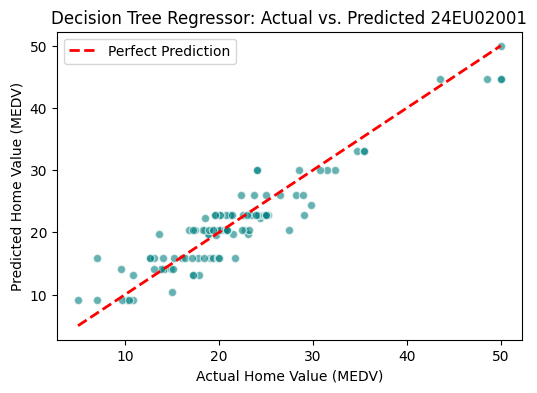

In [48]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test_r, reg_preds, color='teal', alpha=0.6, edgecolor='white')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title("Decision Tree Regressor: Actual vs. Predicted 24EU02001")
plt.xlabel("Actual Home Value (MEDV)")
plt.ylabel("Predicted Home Value (MEDV)")
plt.legend()
plt.show()


In [49]:
import warnings


In [50]:
warnings.filterwarnings("ignore")


In [51]:
import pandas as pd


In [52]:
from sklearn.model_selection import train_test_split


In [53]:
from sklearn.preprocessing import StandardScaler


In [54]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"


In [55]:
sonar_features = [f"F_{i}" for i in range(1, 61)]


In [56]:
sonar_columns = sonar_features + ['Class']


In [57]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)


In [58]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})


In [59]:
X_sonar = sonar_df[sonar_features]


In [60]:
y_sonar = sonar_df['Class_numeric']


In [61]:
scaler_sonar = StandardScaler()


In [62]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)


In [63]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [64]:
print("Sonar Training Set Shape:", X_train_s.shape)


Sonar Training Set Shape: (145, 60)


In [65]:
print("Sonar Test Set Shape:", X_test_s.shape)


Sonar Test Set Shape: (63, 60)


In [66]:
from sklearn.ensemble import BaggingClassifier


In [67]:
from sklearn.metrics import accuracy_score


In [68]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

In [69]:
bagging_model.fit(X_train_s, y_train_s)


BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=50, n_jobs=-1, random_state=42)

In [70]:
bagging_preds = bagging_model.predict(X_test_s)


In [71]:
bagging_accuracy = accuracy_score(y_test_s, bagging_preds)


In [72]:
print(f"Bagging Classifier Test Accuracy: {bagging_accuracy * 100:.2f}%")


Bagging Classifier Test Accuracy: 80.95%


In [73]:
from sklearn.ensemble import RandomForestClassifier


In [74]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)


In [75]:
rf_model.fit(X_train_s, y_train_s)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [76]:
rf_preds = rf_model.predict(X_test_s)


In [77]:
rf_accuracy = accuracy_score(y_test_s, rf_preds)


In [78]:
print(f"Random Forest Classifier Test Accuracy: {rf_accuracy * 100:.2f}%")


Random Forest Classifier Test Accuracy: 82.54%


In [79]:
from sklearn.ensemble import VotingClassifier


In [80]:
from sklearn.linear_model import LogisticRegression


In [81]:
from sklearn.svm import SVC


In [82]:
estimators = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('svc', SVC(probability=True, random_state=42))
]

In [83]:
voting_model = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)


In [84]:
voting_model.fit(X_train_s, y_train_s)


VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=500,
                                                 random_state=42)),
                             ('dt',
                              DecisionTreeClassifier(max_depth=5,
                                                     random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 n_jobs=-1, voting='soft')

In [85]:
voting_preds = voting_model.predict(X_test_s)


In [86]:
voting_accuracy = accuracy_score(y_test_s, voting_preds)


In [87]:
print(f"Voting Classifier Test Accuracy: {voting_accuracy * 100:.2f}%")


Voting Classifier Test Accuracy: 87.30%


In [88]:
import matplotlib.pyplot as plt


In [89]:

import seaborn as sns


In [90]:

ensemble_results = pd.DataFrame({
    'Ensemble Technique': ['Bagging (DT Base)', 'Random Forest', 'Voting Classifier (Soft)'],
    'Test Accuracy (%)': [bagging_accuracy * 100, rf_accuracy * 100, voting_accuracy * 100]
})



In [91]:
print("--- Performance Comparison ---")
print(ensemble_results.to_string(index=False))


--- Performance Comparison ---
      Ensemble Technique  Test Accuracy (%)
       Bagging (DT Base)          80.952381
           Random Forest          82.539683
Voting Classifier (Soft)          87.301587


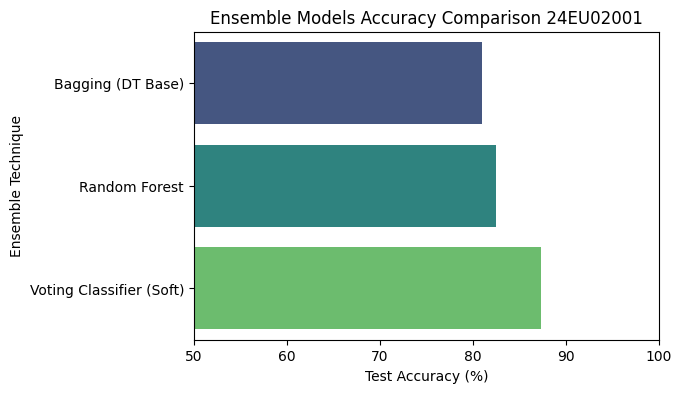

In [92]:
plt.figure(figsize=(6, 4))
sns.barplot(data=ensemble_results, x='Test Accuracy (%)', y='Ensemble Technique', palette='viridis')
plt.xlim([50, 100])
plt.title("Ensemble Models Accuracy Comparison 24EU02001")
plt.show()


In [93]:
import warnings


In [94]:
from sklearn.ensemble import AdaBoostClassifier



In [95]:

from sklearn.metrics import accuracy_score


In [96]:
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)


In [97]:
adaboost_model.fit(X_train_s, y_train_s)



AdaBoostClassifier(random_state=42)

In [98]:


# Evaluate accuracy
ada_preds = adaboost_model.predict(X_test_s)


In [99]:

ada_accuracy = accuracy_score(y_test_s, ada_preds)



In [100]:


print(f"AdaBoost Classifier Test Accuracy: {ada_accuracy * 100:.2f}%")


AdaBoost Classifier Test Accuracy: 85.71%


In [101]:
from sklearn.ensemble import GradientBoostingClassifier



In [102]:

# Initialize and train a baseline Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)



In [103]:

gb_model.fit(X_train_s, y_train_s)



GradientBoostingClassifier(random_state=42)

In [104]:


# Evaluate accuracy
gb_preds = gb_model.predict(X_test_s)


In [105]:

gb_accuracy = accuracy_score(y_test_s, gb_preds)



In [106]:


print(f"Gradient Boosting Classifier Test Accuracy: {gb_accuracy * 100:.2f}%")


Gradient Boosting Classifier Test Accuracy: 80.95%


In [107]:
from sklearn.model_selection import GridSearchCV


In [108]:
# Define parameter grid for Gradient Boosting
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5]
}

In [109]:
# Run Grid Search
grid_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [110]:
grid_gb.fit(X_train_s, y_train_s)


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.05, 0.1],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

In [111]:
best_gb = grid_gb.best_estimator_


In [112]:
tuned_gb_preds = best_gb.predict(X_test_s)


In [113]:
tuned_gb_accuracy = accuracy_score(y_test_s, tuned_gb_preds)


In [114]:
print("Optimal Hyperparameters Selected:", grid_search_params := grid_gb.best_params_)


Optimal Hyperparameters Selected: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}


In [115]:
print(f"Tuned Gradient Boosting Test Accuracy: {tuned_gb_accuracy * 100:.2f}%")


Tuned Gradient Boosting Test Accuracy: 74.60%


In [116]:
# Assemble master performance records
master_comparison = pd.DataFrame({
    'Model Classifier': [
        'Bagging Classifier',
        'Random Forest Classifier',
        'Voting Ensemble (Soft)',
        'AdaBoost Classifier',
        'Base Gradient Boosting',
        'Tuned Gradient Boosting'
    ],
    'Accuracy (%)': [
        bagging_accuracy * 100,
        rf_accuracy * 100,
        voting_accuracy * 100,
        ada_accuracy * 100,
        gb_accuracy * 100,
        tuned_gb_accuracy * 100
    ]
}).sort_values(by='Accuracy (%)', ascending=False)

In [117]:
print("--- Master Performance Table: Tasks 2 & 3 ---")


--- Master Performance Table: Tasks 2 & 3 ---


In [118]:
print(master_comparison.to_string(index=False))


        Model Classifier  Accuracy (%)
  Voting Ensemble (Soft)     87.301587
     AdaBoost Classifier     85.714286
Random Forest Classifier     82.539683
      Bagging Classifier     80.952381
  Base Gradient Boosting     80.952381
 Tuned Gradient Boosting     74.603175


In [119]:
import matplotlib.pyplot as plt


In [120]:
import numpy as np


In [121]:
rf_importances = rf_model.feature_importances_


In [122]:
gb_importances = best_gb.feature_importances_


In [123]:
top_indices_rf = np.argsort(rf_importances)[-10:]


In [124]:
top_indices_gb = np.argsort(gb_importances)[-10:]


In [125]:
features_list = [f"F_{i}" for i in range(1, 61)]


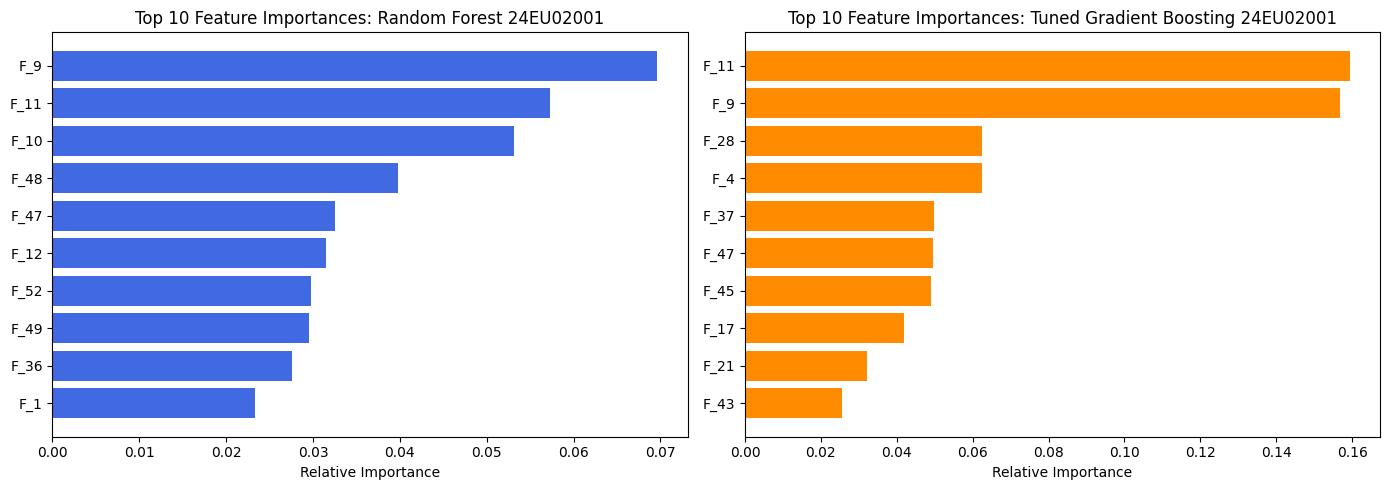

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Random Forest Importances
axes[0].barh(range(10), rf_importances[top_indices_rf], color='royalblue', align='center')
axes[0].set_yticks(range(10))
axes[0].set_yticklabels([features_list[i] for i in top_indices_rf])
axes[0].set_title("Top 10 Feature Importances: Random Forest 24EU02001")
axes[0].set_xlabel("Relative Importance")

# Plot Tuned Gradient Boosting Importances
axes[1].barh(range(10), gb_importances[top_indices_gb], color='darkorange', align='center')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([features_list[i] for i in top_indices_gb])
axes[1].set_title("Top 10 Feature Importances: Tuned Gradient Boosting 24EU02001")
axes[1].set_xlabel("Relative Importance")

plt.tight_layout()
plt.show()